# Maduro Capture Markets — Van Dyke Case

**Background:** U.S. Army Special Forces Master Sgt. Gannon Van Dyke was charged with
using classified information about a planned U.S. operation to capture Venezuelan leader
Nicolás Maduro to place bets on Polymarket prediction markets.

This notebook analyses the bet-level data (size, direction, timing) across all major
Maduro capture/removal markets to surface patterns consistent with informed trading.

**Chart legend:**  
● Green = BUY YES (betting Maduro captured / removed)  
● Red = BUY NO (betting he stays)  
▲ Triangle = SELL (exiting a position)  
Blue line = YES implied probability over time

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import httpx, sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime, timedelta

sys.path.insert(0, str(Path('..')))
from clob import ClobAPI

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10,
                     'axes.labelsize': 9, 'xtick.labelsize': 7,
                     'ytick.labelsize': 7, 'legend.fontsize': 7})

C_YES   = '#2ea043'
C_NO    = '#cf222e'
C_PRICE = '#0075ca'
C_NET   = '#6e40c9'

fmt_usdc = mticker.FuncFormatter(
    lambda v, _: f'\${abs(v)/1e6:.1f}M' if abs(v) >= 1e6
    else f'\${abs(v)/1e3:.0f}K' if abs(v) >= 1e3 else f'\${abs(v):.0f}'
)
print('Libraries loaded')

<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_87923/2261003629.py:29: SyntaxWarning: invalid escape sequence '\$'
  lambda v, _: f'\${abs(v)/1e6:.1f}M' if abs(v) >= 1e6
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_87923/2261003629.py:30: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v) >= 1e3 else f'\${abs(v):.0f}'
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_87923/2261003629.py:30: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v) >= 1e3 else f'\${abs(v):.0f}'


Libraries loaded


In [2]:
# All major Maduro markets — ordered by relevance to the Van Dyke case
MARKETS = [
    {
        'question':    'Maduro in U.S. custody by January 31?',
        'condition_id':'0xbfa45527ec959aacc36f7c312bd4f328171a7681ef1aeb3a7e34db5fb47d3f1d',
        'token_yes':   '70234639419415803936237775088941650861420',
        'resolution':  'No',
        'volume_m':    11.03,
        'slug':        'maduro-in-us-custody-by-january-31',
    },
    {
        'question':    'Maduro out in 2025?',
        'condition_id':'0xafc235557ace53ff0b0d2e93392314a7c3f3daab26a79050e985c11282f66df7',
        'token_yes':   '4534348065369457780717750591466440566920',
        'resolution':  'No',
        'volume_m':    34.64,
        'slug':        'maduro-out-in-2025-411',
    },
    {
        'question':    'Maduro out by January 31, 2026?',
        'condition_id':'0x580adc1327de9bf7c179ef5aaffa3377bb5cb252b7d6390b027172d43fd6f993',
        'token_yes':   '2491806774766175904872013560768793420917',
        'resolution':  'No',
        'volume_m':    10.97,
        'slug':        'maduro-out-by-january-31-2026-318',
    },
    {
        'question':    'Maduro out by November 30, 2025?',
        'condition_id':'0xa953bea944d7264285c0a2cc1f92809a7d9db78138b1c3de9cc23d8917f14d6a',
        'token_yes':   '3585939031565639206045407326754781836499',
        'resolution':  'No',
        'volume_m':    5.57,
        'slug':        'maduro-out-by-november-30-2025',
    },
    {
        'question':    'Maduro out by March 31, 2026?',
        'condition_id':'0x18d8c59309811ce5618ea941f9bde2a96afa5d876a69c42fba2da4bcc56d3c5e',
        'token_yes':   '4738045222875171307032272609767607444950',
        'resolution':  'No',
        'volume_m':    3.79,
        'slug':        'maduro-out-by-march-31-2026-187-483',
    },
    {
        'question':    'Fact Check: Maduro capture staged?',
        'condition_id':'0x4cd373cd35f29c39a4fb45b7c31f8619d142aec0b4f863245510d1b3169c5502',
        'token_yes':   '8406947393516535197227670523638355616968',
        'resolution':  'No',
        'volume_m':    1.08,
        'slug':        'fact-check-maduro-capture-staged',
    },
    {
        'question':    'Maduro in U.S. custody by December 31?',
        'condition_id':'0xc9aea75023b81578a98479326ebc8655ff61602a693f1f07930229eb1c496e0c',
        'token_yes':   '8561754518425248791282886901243495801962',
        'resolution':  'No',
        'volume_m':    0.38,
        'slug':        'maduro-in-us-custody-by-december-31',
    },
    {
        'question':    'U.S. operation to capture Maduro in 2025?',
        'condition_id':'0x69ac865d7824f22808d29deec2ed5090eaeeb27094e6936970c4b4c5660a87d5',
        'token_yes':   '8703863351595011636388411351121309839927',
        'resolution':  'No',
        'volume_m':    0.12,
        'slug':        'us-operation-to-capture-maduro-in-2025',
    },
]
print(f'{len(MARKETS)} markets defined')
for m in MARKETS:
    print(f'  [{m["volume_m"]:>6.2f}M] {m["question"]}')

8 markets defined
  [ 11.03M] Maduro in U.S. custody by January 31?
  [ 34.64M] Maduro out in 2025?
  [ 10.97M] Maduro out by January 31, 2026?
  [  5.57M] Maduro out by November 30, 2025?
  [  3.79M] Maduro out by March 31, 2026?
  [  1.08M] Fact Check: Maduro capture staged?
  [  0.38M] Maduro in U.S. custody by December 31?
  [  0.12M] U.S. operation to capture Maduro in 2025?


In [3]:
def fetch_trades(condition_id: str) -> pl.DataFrame:
    """Fetch up to ~3,000 most-recent fills for a market."""
    rows, seen = [], set()
    with httpx.Client(base_url='https://data-api.polymarket.com', timeout=30) as client:
        for offset in range(0, 3000, 500):
            try:
                data = client.get('/trades',
                    params={'market': condition_id, 'limit': 500, 'offset': offset}
                ).json()
                if not isinstance(data, list) or not data: break
                for r in data:
                    h = r.get('transactionHash', str(r.get('timestamp','')))
                    if h not in seen:
                        seen.add(h)
                        rows.append(r)
                if len(data) < 500: break
            except Exception: break
    if not rows: return pl.DataFrame()
    return (
        pl.DataFrame({
            'timestamp': [int(r.get('timestamp', 0))  for r in rows],
            'price':     [float(r.get('price', 0))    for r in rows],
            'size':      [float(r.get('size', 0))     for r in rows],
            'side':      [str(r.get('side', ''))      for r in rows],
            'outcome':   [str(r.get('outcome', ''))   for r in rows],
            'wallet':    [str(r.get('proxyWallet',''))for r in rows],
            'tx_hash':   [str(r.get('transactionHash','')) for r in rows],
        })
        .sort('timestamp')
        .with_columns([
            (pl.col('timestamp') * 1_000_000).cast(pl.Datetime('us')).alias('date'),
            pl.when(pl.col('outcome').str.to_lowercase() == 'yes').then(pl.lit('Yes'))
              .when(pl.col('outcome').str.to_lowercase() == 'no').then(pl.lit('No'))
              .otherwise(pl.col('outcome')).alias('outcome'),
        ])
    )

import asyncio

def fetch_price_history(token_id: str) -> pl.DataFrame:
    """Fetch daily OHLC price history from CLOB."""
    async def _fetch():
        async with ClobAPI() as clob:
            return await clob.get_prices_history(token_id, interval='max', fidelity=1440)
    try:
        result = asyncio.run(_fetch())
        hist = result.get('history', [])
        if not hist: return pl.DataFrame()
        return (
            pl.DataFrame({'timestamp': [int(p['t']) for p in hist],
                          'price':     [float(p['p']) for p in hist]})
            .with_columns((pl.col('timestamp') * 1_000_000)
                           .cast(pl.Datetime('us')).alias('date'))
        )
    except Exception as ex:
        print(f'    price history error: {ex}')
        return pl.DataFrame()

print('Fetch functions ready')

Fetch functions ready


## Per-market bet analysis
Markets ordered by relevance to the Van Dyke case (largest / most directly related first).


Fetching: Maduro in U.S. custody by January 31?


    price history error: asyncio.run() cannot be called from a running event loop
  2517 fills / 1103 wallets / span=3.7d / bucket=2 hr
  BUY YES (captured/gone): $1,625K  (17%)
  BUY NO  (stays):         $8,006K  (83%)
  Resolution → No  |  NO bettors PROFITED
  Top 5 bets:
    $ 1,509,322  BUY   No    05 Jan 21:59  wallet=0xda12740a3c...
    $ 1,076,990  BUY   No    06 Jan 07:01  wallet=0x06577a03c1...
    $   499,180  BUY   No    06 Jan 06:55  wallet=0x06577a03c1...
    $   265,521  BUY   Yes   03 Jan 22:29  wallet=0xdbade4c82f...
    $   250,000  BUY   No    07 Jan 00:04  wallet=0x066604ffd7...


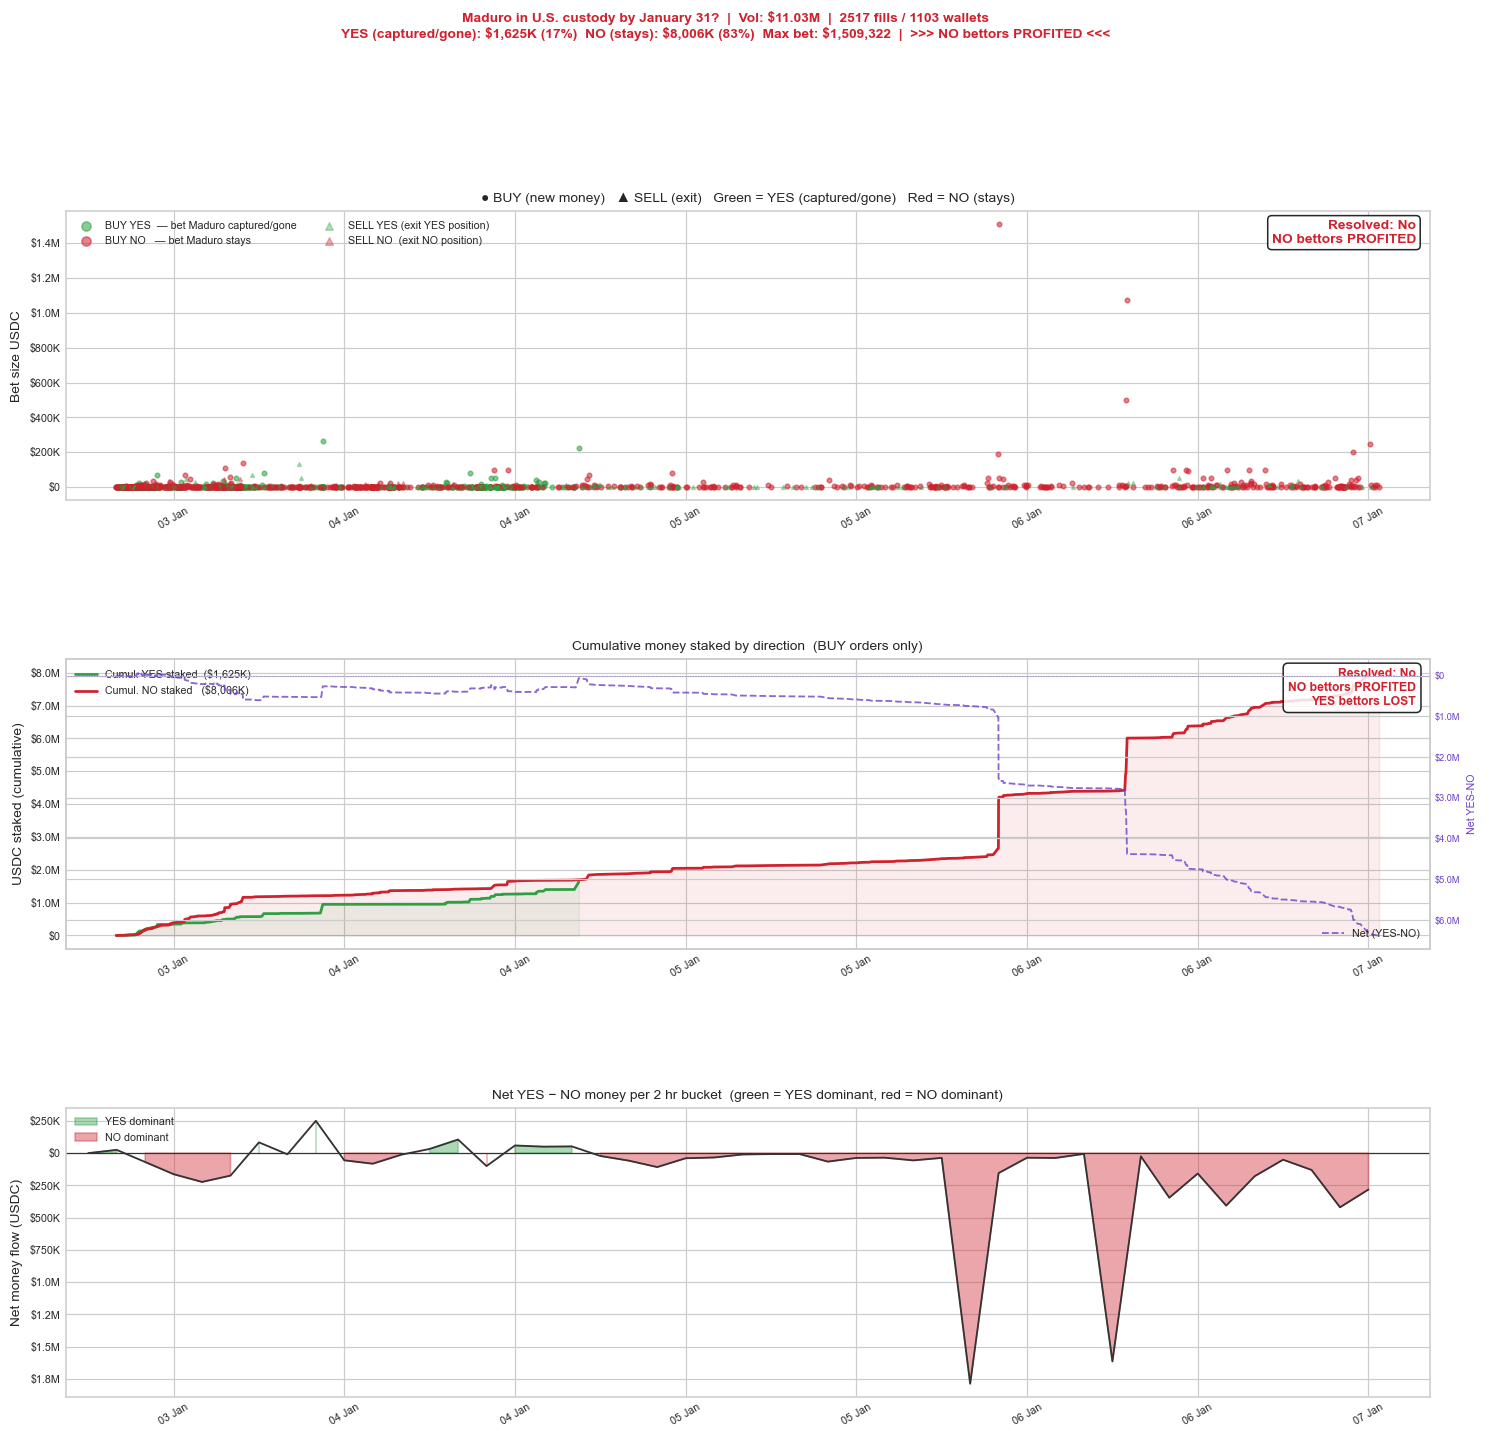


Fetching: Maduro out in 2025?


    price history error: asyncio.run() cannot be called from a running event loop
  3000 fills / 1890 wallets / span=2.9d / bucket=2 hr
  BUY YES (captured/gone): $1,417K  (68%)
  BUY NO  (stays):         $671K  (32%)
  Resolution → No  |  NO bettors PROFITED
  Top 5 bets:
    $   752,655  SELL  Yes   31 Dec 05:05  wallet=0x168b100d7a...
    $   300,480  SELL  Yes   31 Dec 05:11  wallet=0xbf32f7a77c...
    $   191,880  SELL  Yes   31 Dec 08:40  wallet=0x3a8651c42a...
    $   148,024  BUY   Yes   31 Dec 03:37  wallet=0x168b100d7a...
    $   137,174  SELL  Yes   31 Dec 14:30  wallet=0xeb7fd9831e...


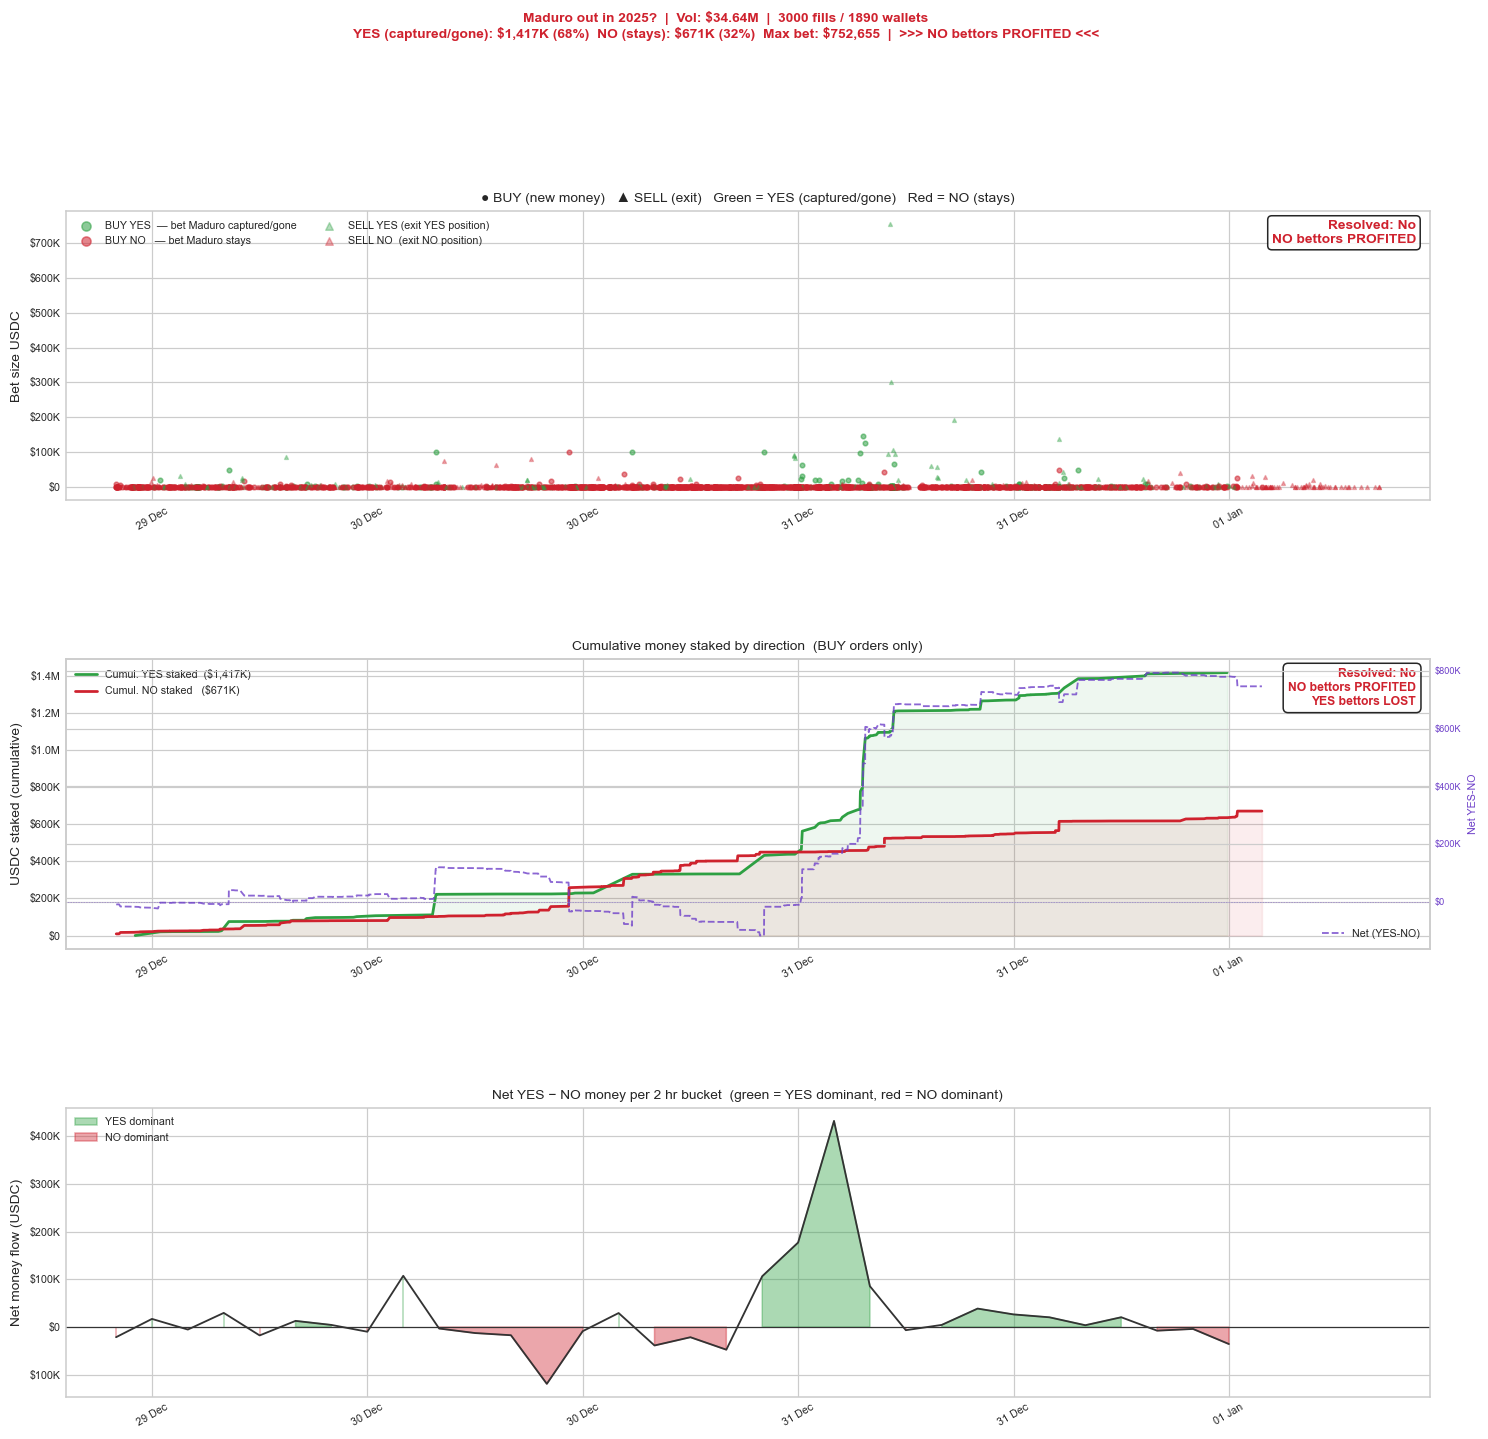


Fetching: Maduro out by January 31, 2026?


    price history error: asyncio.run() cannot be called from a running event loop
  3000 fills / 1360 wallets / span=0.2d / bucket=10 min
  BUY YES (captured/gone): $2,390K  (46%)
  BUY NO  (stays):         $2,774K  (54%)
  Resolution → No  |  NO bettors PROFITED
  Top 5 bets:
    $   500,000  BUY   Yes   03 Jan 11:09  wallet=0x94cff0a688...
    $   192,904  BUY   No    03 Jan 10:02  wallet=0x2844da5da0...
    $   183,865  BUY   No    03 Jan 09:48  wallet=0xfe6fb0b683...
    $   150,000  BUY   Yes   03 Jan 09:39  wallet=0x59cd67a7a9...
    $   148,090  BUY   No    03 Jan 12:13  wallet=0x56dae0074d...


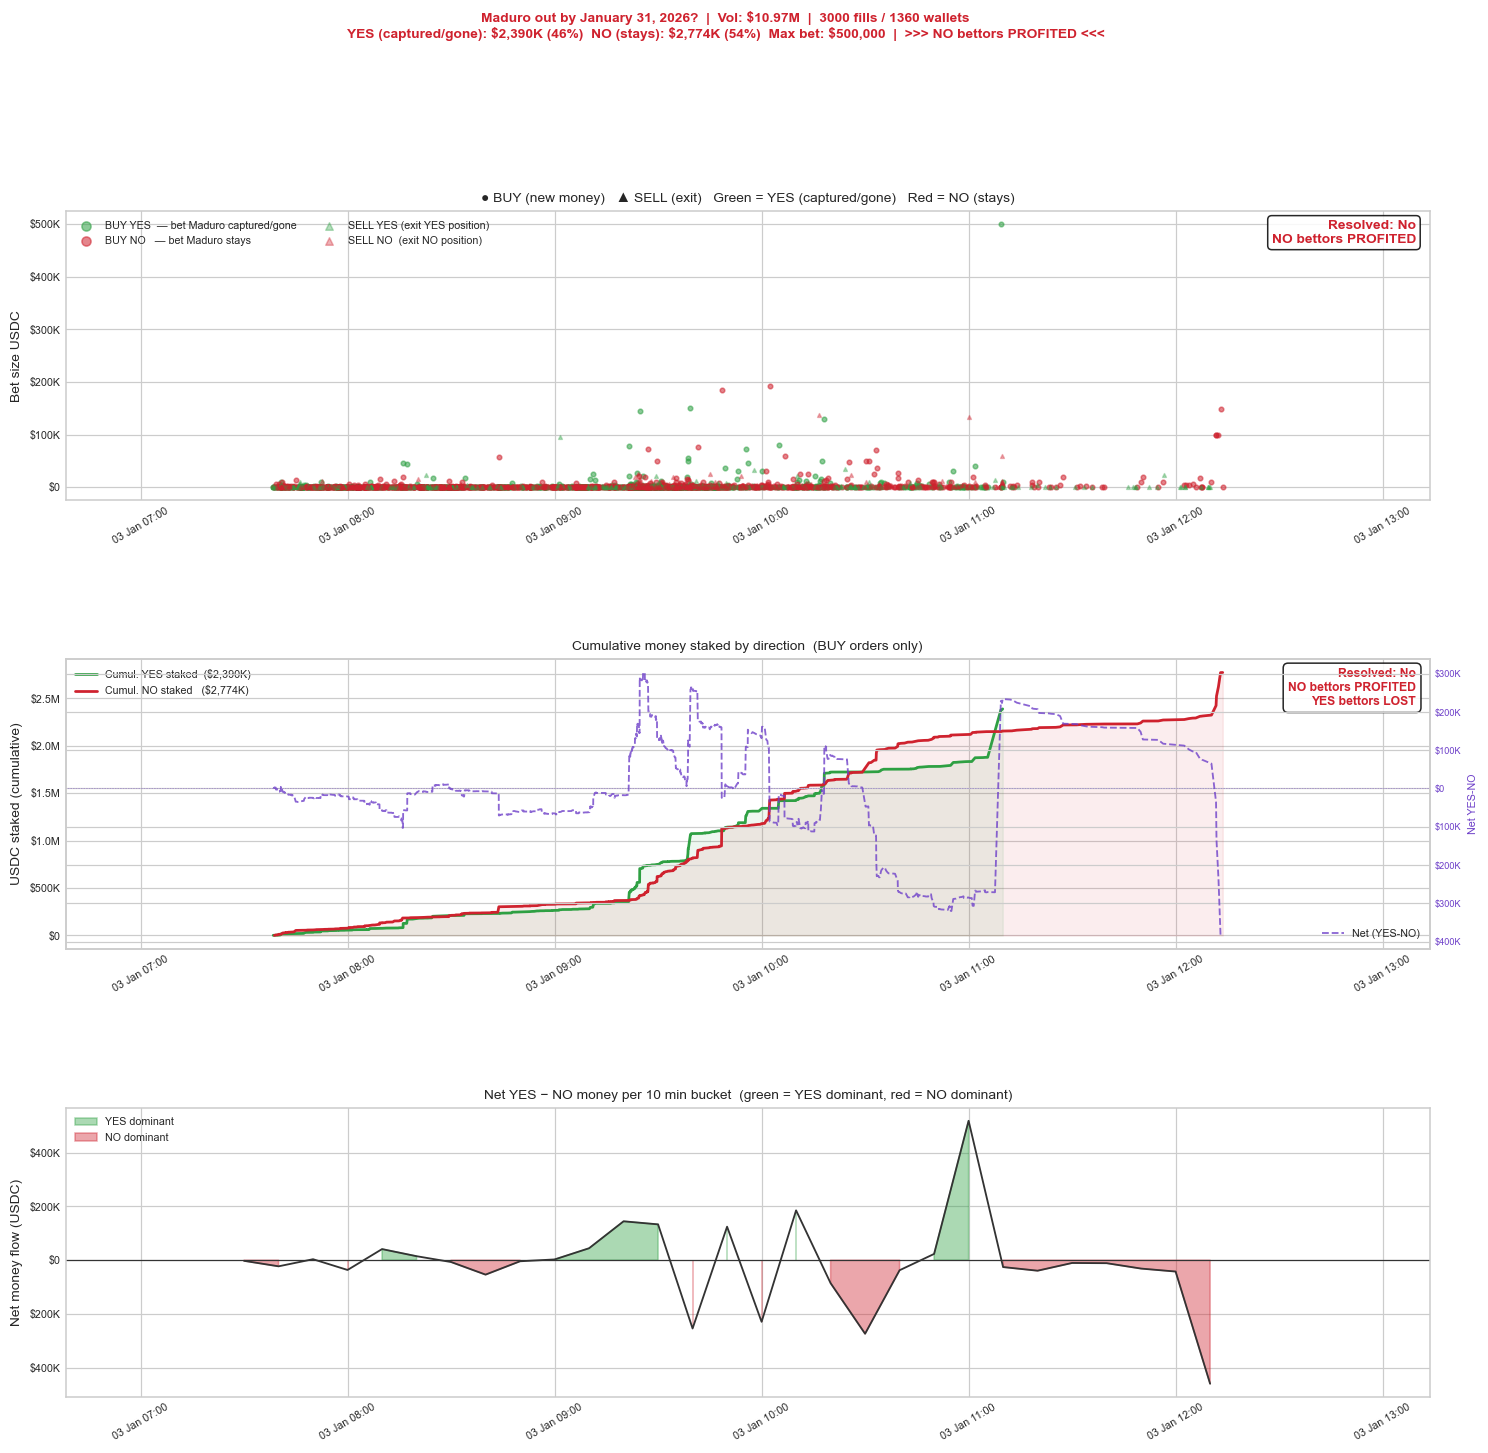


Fetching: Maduro out by November 30, 2025?


    price history error: asyncio.run() cannot be called from a running event loop
  3000 fills / 1996 wallets / span=5.6d / bucket=4 hr
  BUY YES (captured/gone): $809K  (42%)
  BUY NO  (stays):         $1,114K  (58%)
  Resolution → No  |  NO bettors PROFITED
  Top 5 bets:
    $   113,624  BUY   No    29 Nov 16:31  wallet=0x000d257d2d...
    $   101,910  BUY   No    28 Nov 01:59  wallet=0x9d3e4fb265...
    $    55,630  SELL  Yes   01 Dec 02:17  wallet=0xe9063d83df...
    $    51,412  BUY   Yes   29 Nov 13:45  wallet=0x74471a007d...
    $    49,246  BUY   Yes   29 Nov 12:47  wallet=0xce66940dfe...


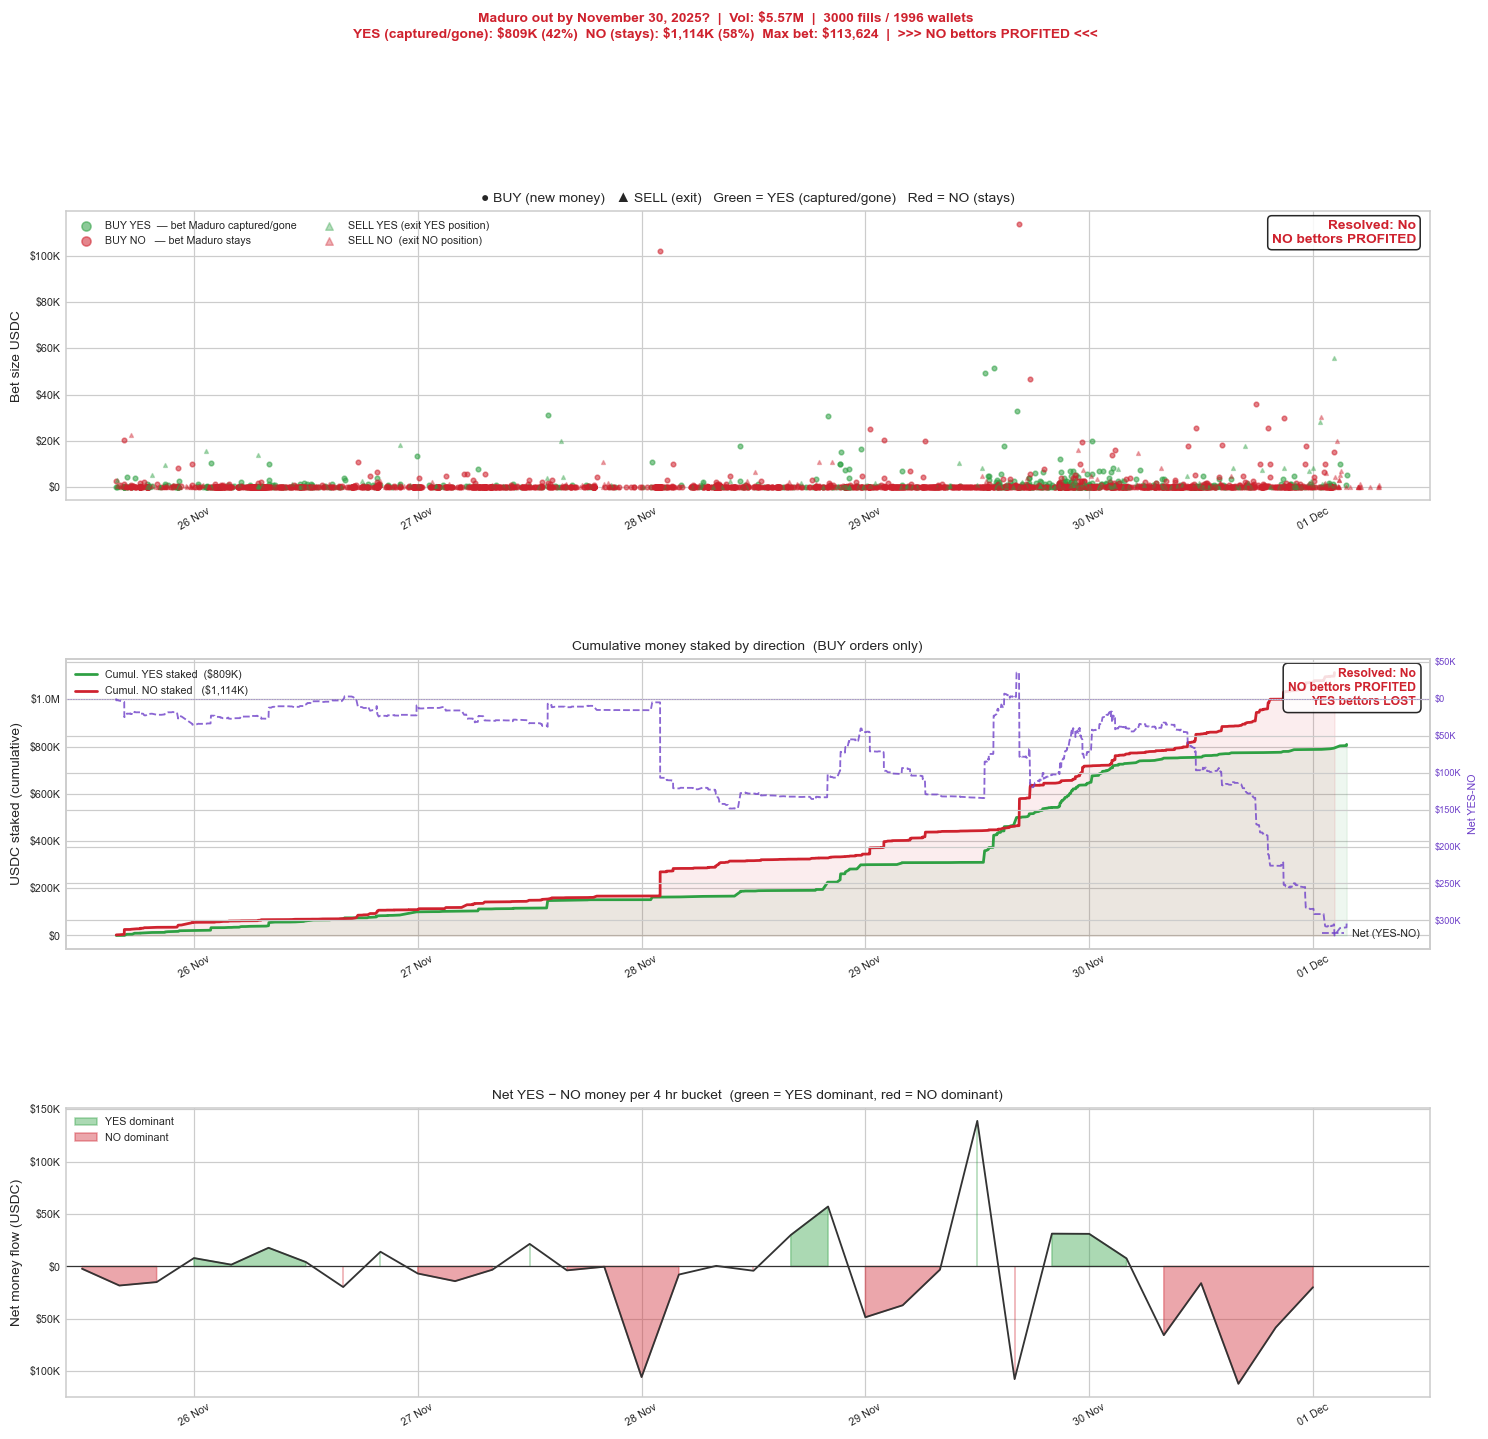


Fetching: Maduro out by March 31, 2026?


    price history error: asyncio.run() cannot be called from a running event loop
  3000 fills / 973 wallets / span=9.7d / bucket=6 hr
  BUY YES (captured/gone): $711K  (66%)
  BUY NO  (stays):         $372K  (34%)
  Resolution → No  |  NO bettors PROFITED
  Top 5 bets:
    $   117,242  BUY   Yes   03 Jan 11:12  wallet=0x1521b47bf0...
    $    63,091  BUY   Yes   03 Jan 09:24  wallet=0xc5adc0dc25...
    $    61,639  SELL  Yes   03 Jan 11:08  wallet=0x44de2a52d8...
    $    50,000  BUY   Yes   03 Jan 11:12  wallet=0x1521b47bf0...
    $    50,000  BUY   Yes   03 Jan 11:12  wallet=0xfcf2378f20...


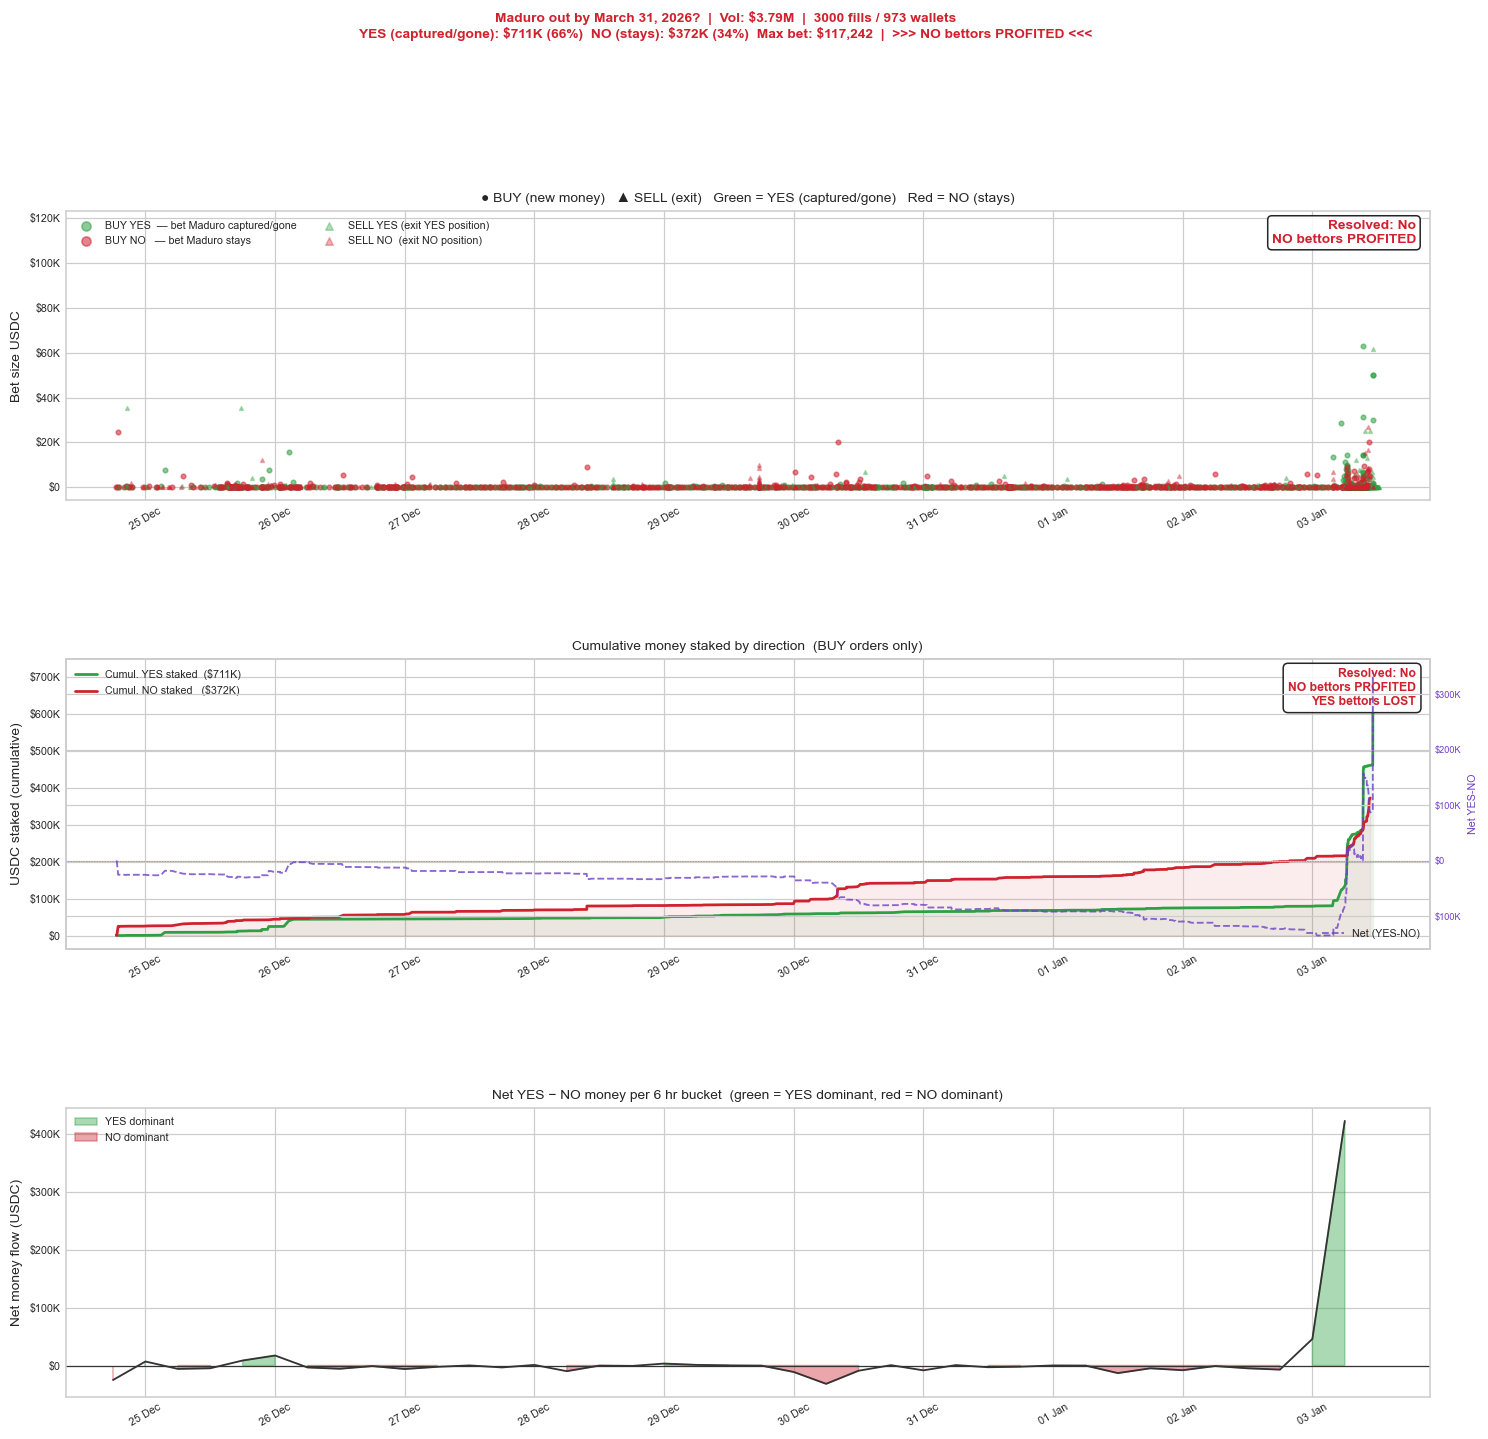


Fetching: Fact Check: Maduro capture staged?


    price history error: asyncio.run() cannot be called from a running event loop
  3000 fills / 1266 wallets / span=84.5d / bucket=1 day
  BUY YES (captured/gone): $351K  (65%)
  BUY NO  (stays):         $192K  (35%)
  Resolution → No  |  NO bettors PROFITED
  Top 5 bets:
    $   116,752  SELL  Yes   24 Feb 12:23  wallet=0x35b9e5a874...
    $    41,426  SELL  Yes   07 Jan 08:28  wallet=0x35b9e5a874...
    $    31,776  SELL  Yes   24 Feb 14:16  wallet=0x35b9e5a874...
    $    24,952  BUY   No    23 Mar 03:27  wallet=0x3e5b23e9f7...
    $    20,174  SELL  Yes   22 Feb 06:37  wallet=0x35b9e5a874...


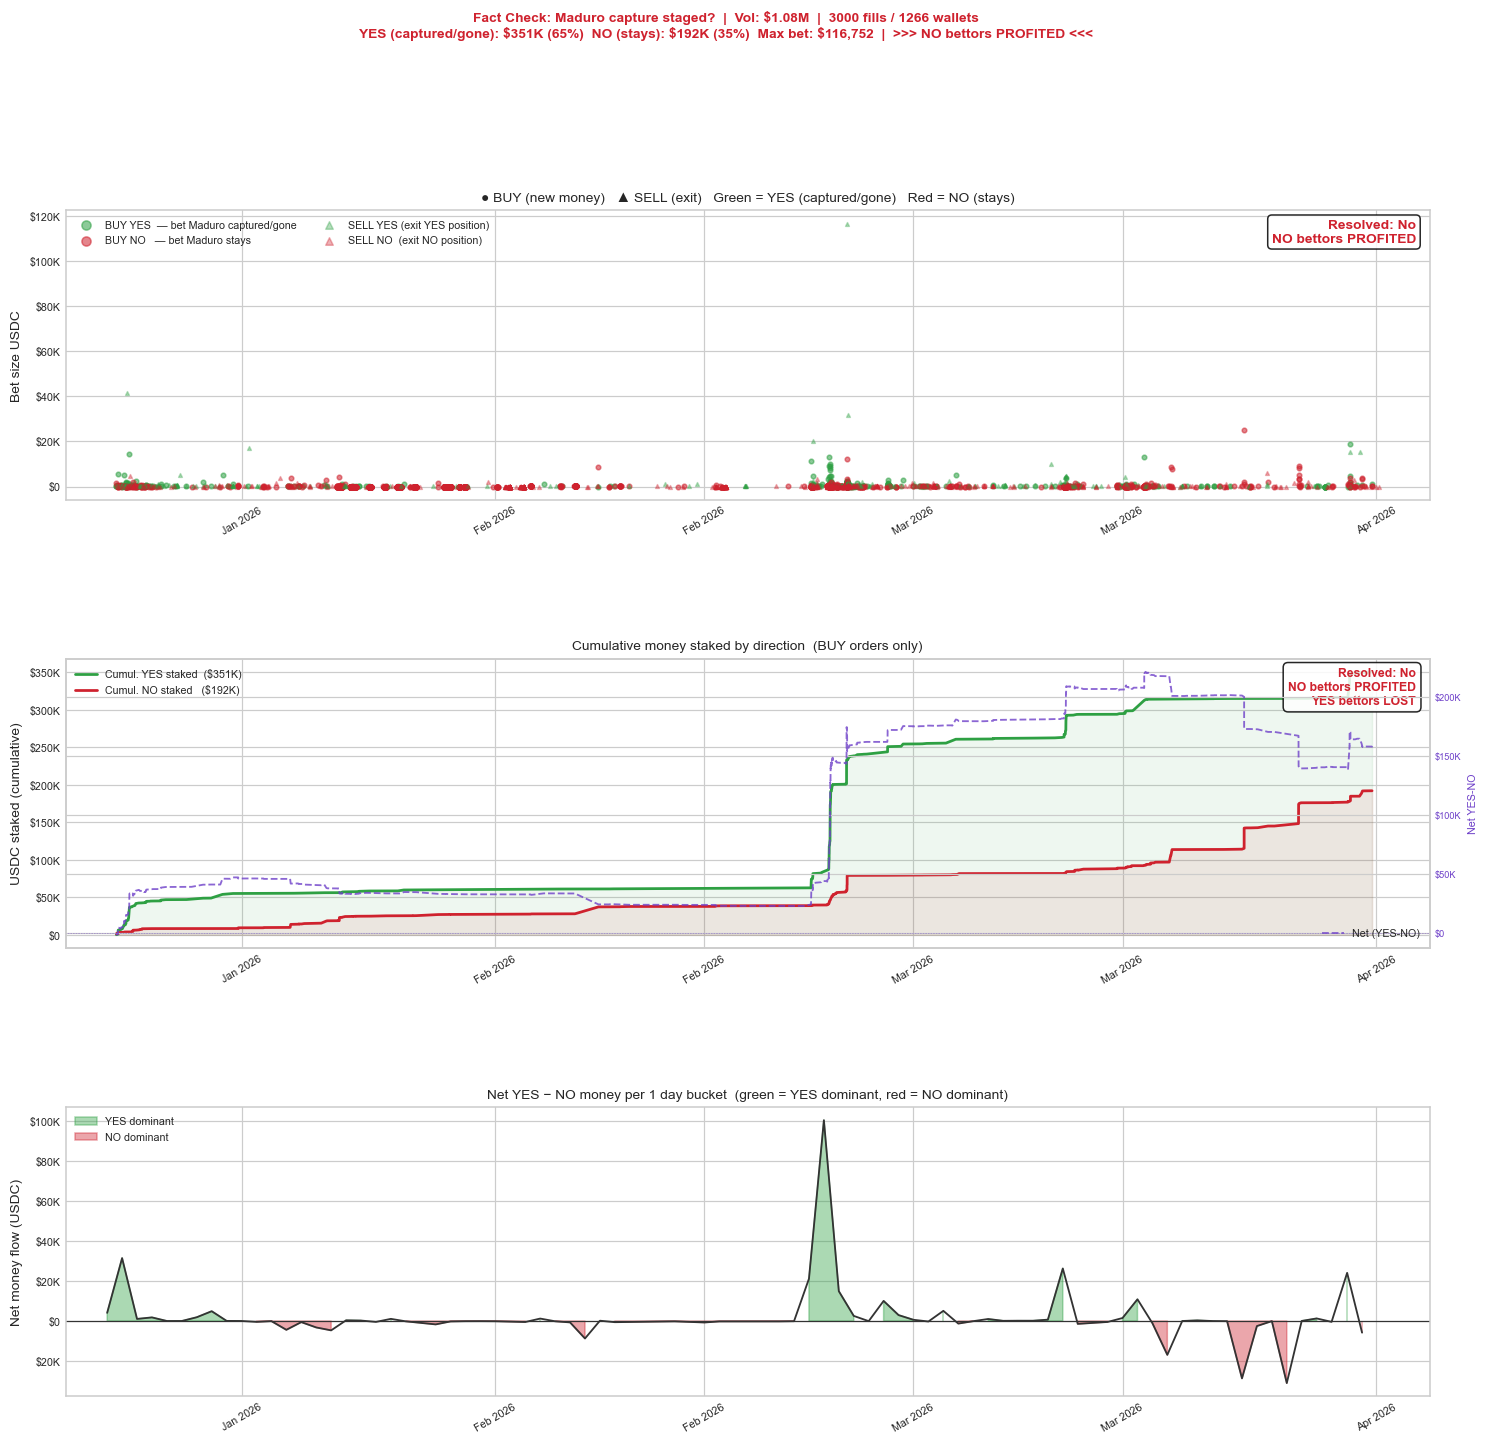


Fetching: Maduro in U.S. custody by December 31?
    price history error: asyncio.run() cannot be called from a running event loop
  766 fills / 395 wallets / span=44.1d / bucket=1 day
  BUY YES (captured/gone): $193K  (68%)
  BUY NO  (stays):         $90K  (32%)
  Resolution → No  |  NO bettors PROFITED
  Top 5 bets:
    $    16,707  BUY   Yes   25 Dec 14:51  wallet=0x36c2b074b2...
    $    16,075  BUY   Yes   20 Nov 05:39  wallet=0xe51c0cc3a2...
    $    12,354  SELL  Yes   29 Dec 07:30  wallet=0xd68ef3de80...
    $    11,538  SELL  Yes   27 Dec 08:38  wallet=0x6ef589efb6...
    $    10,449  BUY   Yes   25 Dec 05:25  wallet=0x714e43a705...


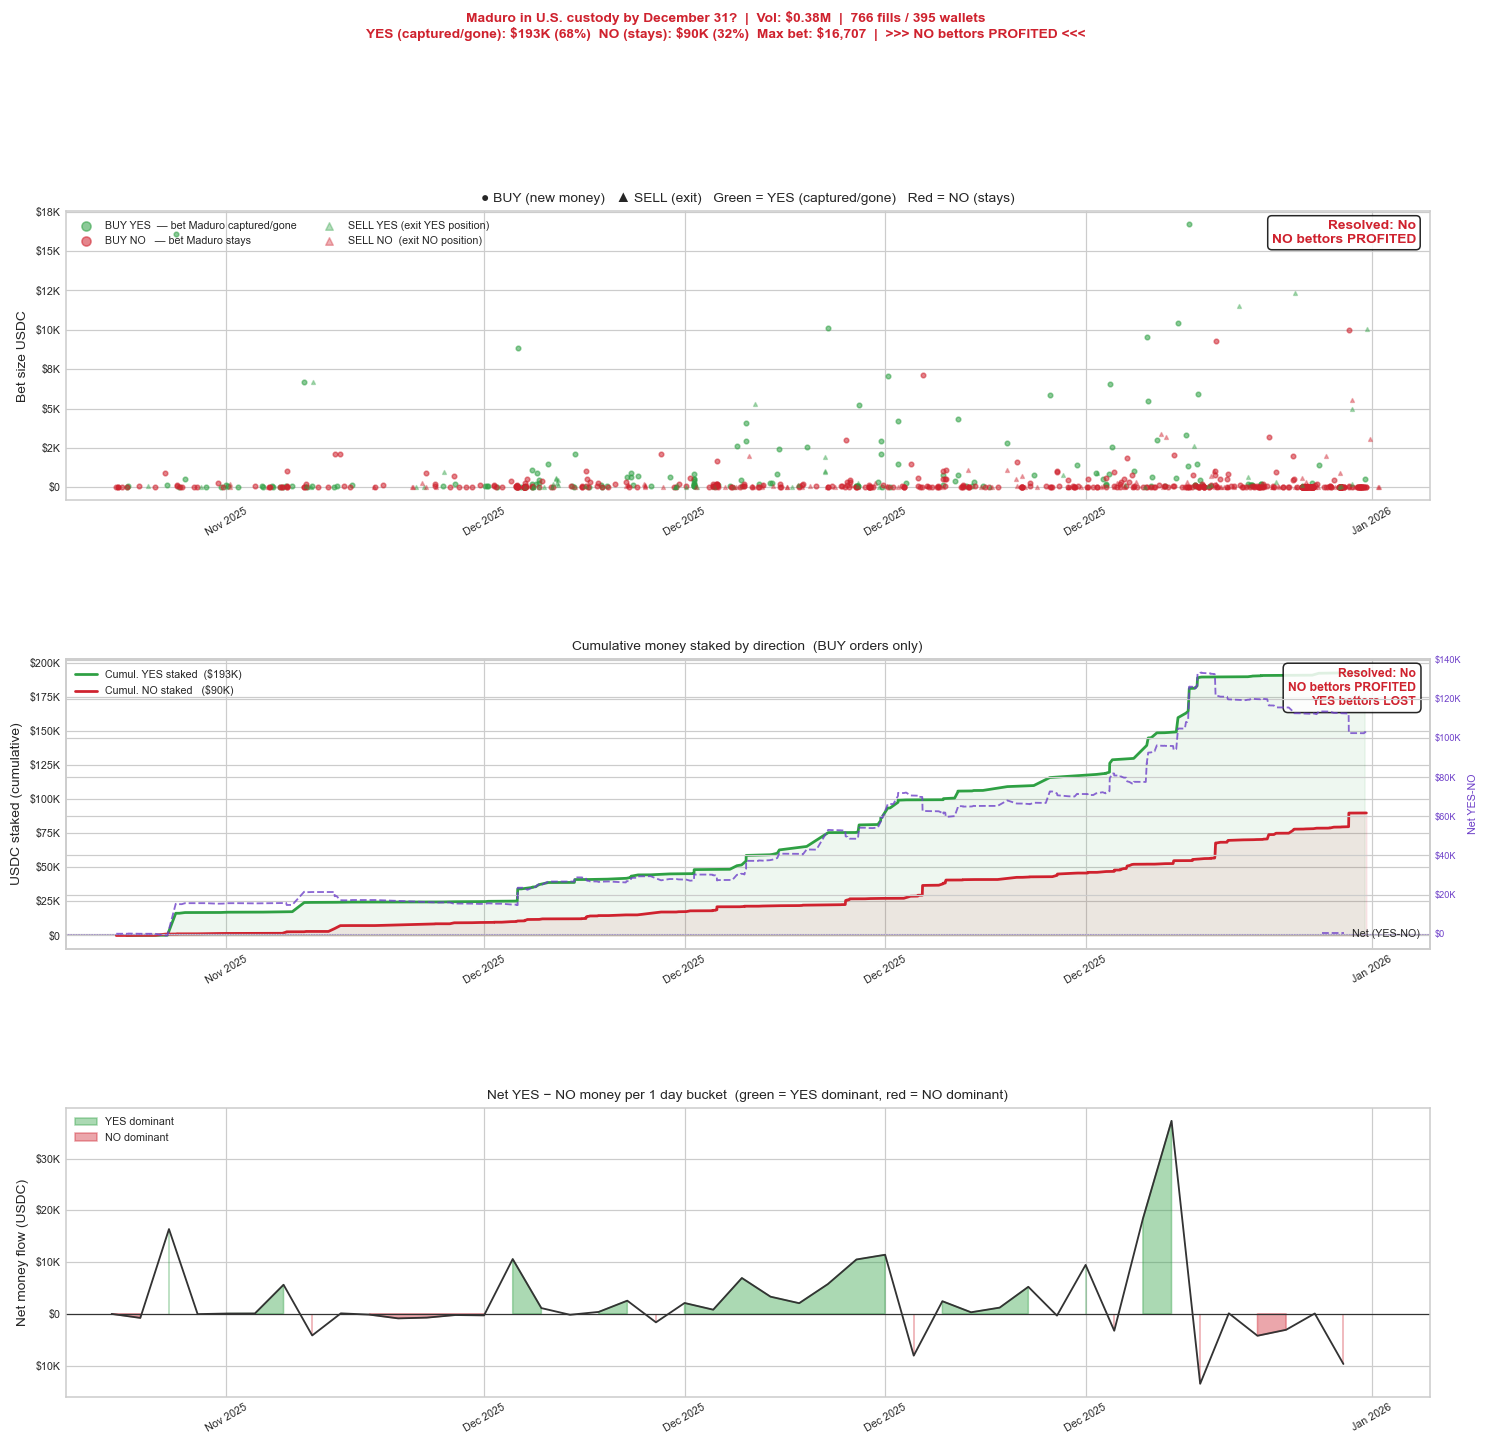


Fetching: U.S. operation to capture Maduro in 2025?
    price history error: asyncio.run() cannot be called from a running event loop
  531 fills / 263 wallets / span=43.0d / bucket=1 day
  BUY YES (captured/gone): $62K  (63%)
  BUY NO  (stays):         $37K  (37%)
  Resolution → No  |  NO bettors PROFITED
  Top 5 bets:
    $     9,820  BUY   Yes   13 Dec 00:24  wallet=0xf3d2440cee...
    $     8,309  SELL  Yes   31 Dec 16:42  wallet=0x858d551d07...
    $     8,172  BUY   Yes   25 Dec 21:47  wallet=0x36c2b074b2...
    $     5,398  BUY   No    26 Dec 13:57  wallet=0x2079cf38a4...
    $     5,214  BUY   Yes   17 Dec 12:50  wallet=0x80c5b2b9d0...


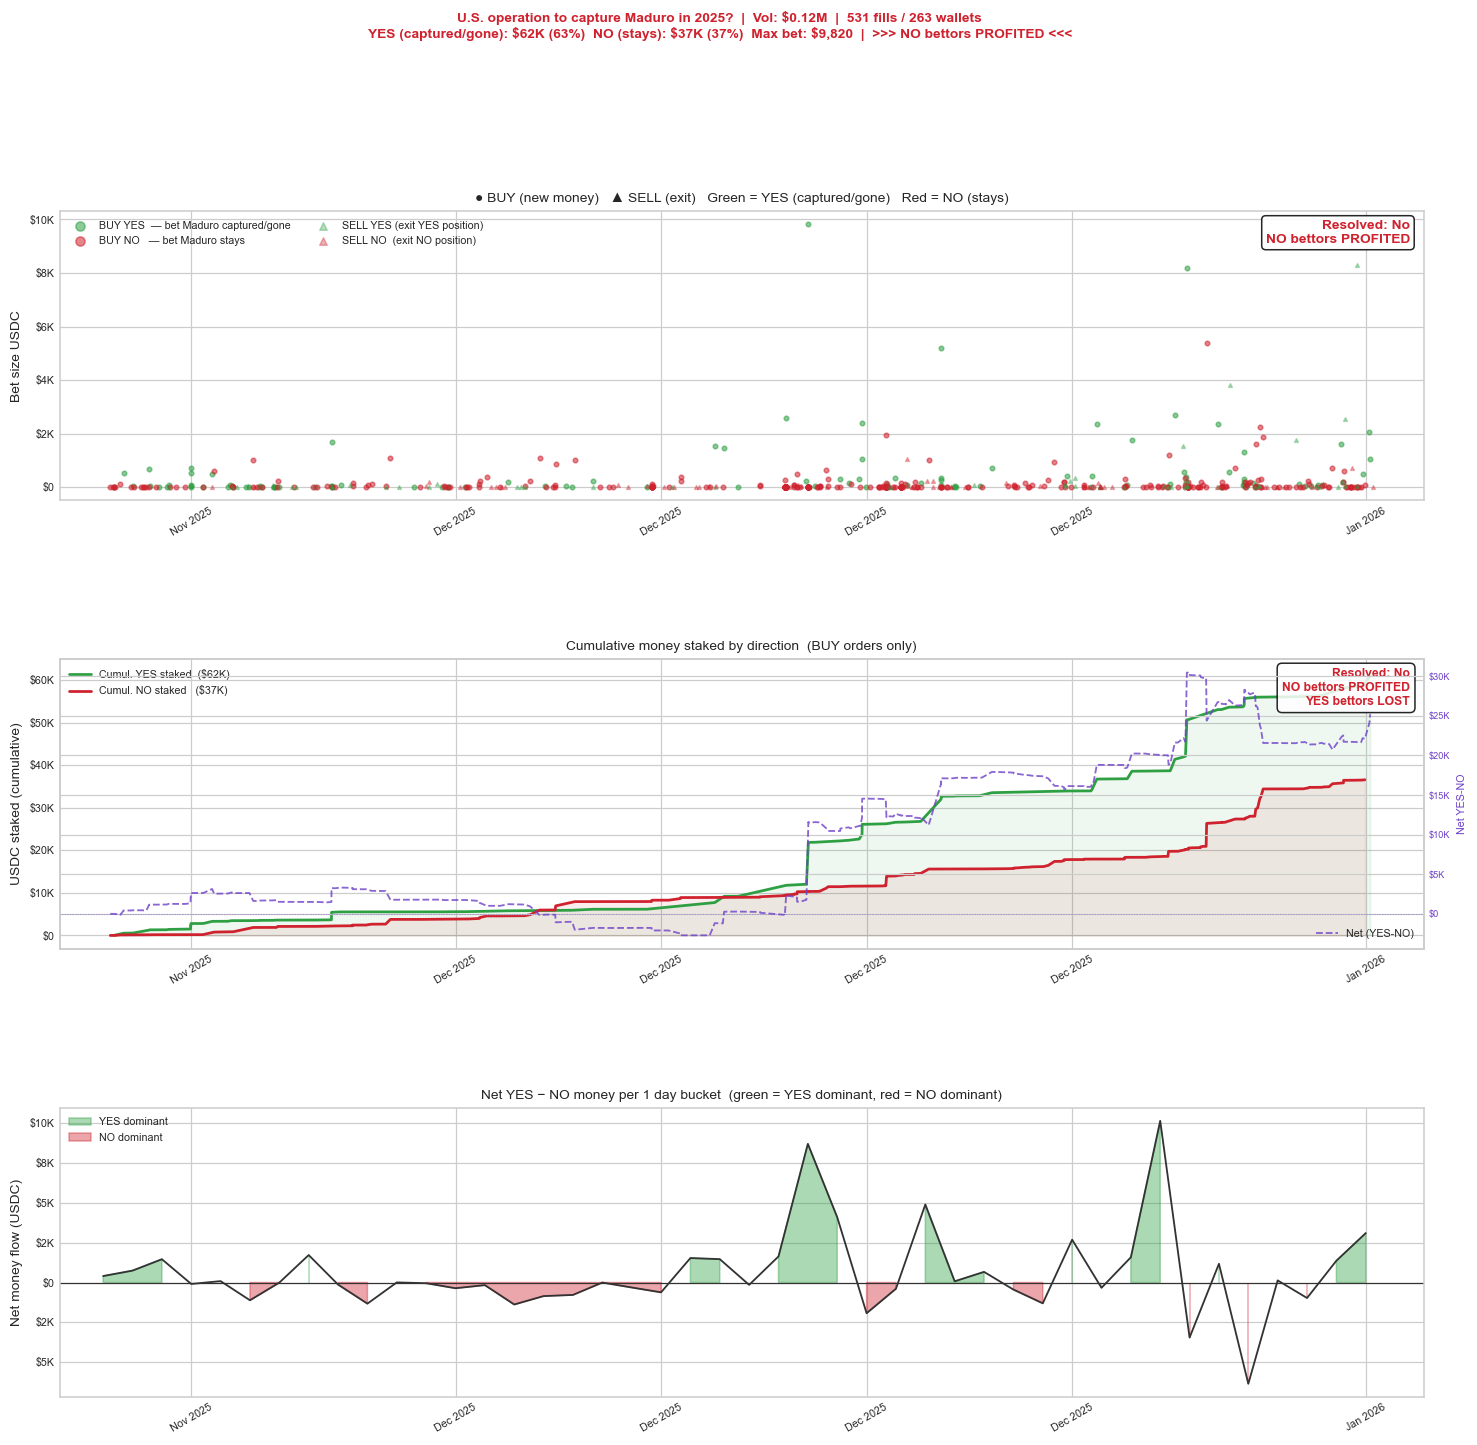

In [4]:
for mkt in MARKETS:
    question   = mkt['question']
    cond_id    = mkt['condition_id']
    token_yes  = mkt['token_yes']
    resolution = mkt['resolution']
    vol_m      = mkt['volume_m']
    yes_won    = (resolution == 'Yes')
    c_winner   = C_YES if yes_won else C_NO
    c_loser    = C_NO  if yes_won else C_YES

    print(f'\nFetching: {question}')
    tr = fetch_trades(cond_id)
    ph = fetch_price_history(token_yes)

    if tr.is_empty():
        print('  No trade data'); continue

    # ── Segment by direction ─────────────────────────────────────────────
    yes_buy  = tr.filter((pl.col('side') == 'BUY')  & (pl.col('outcome') == 'Yes'))
    no_buy   = tr.filter((pl.col('side') == 'BUY')  & (pl.col('outcome') == 'No'))
    yes_sell = tr.filter((pl.col('side') == 'SELL') & (pl.col('outcome') == 'Yes'))
    no_sell  = tr.filter((pl.col('side') == 'SELL') & (pl.col('outcome') == 'No'))

    yes_buy_vol = float(yes_buy['size'].sum() or 0)
    no_buy_vol  = float(no_buy['size'].sum()  or 0)
    total_s     = yes_buy_vol + no_buy_vol
    yes_pct     = 100 * yes_buy_vol / total_s if total_s else 0
    max_bet     = float(tr['size'].max() or 0)
    n_wallets   = tr['wallet'].n_unique()

    ts_min  = int(tr['timestamp'].min())
    ts_max  = int(tr['timestamp'].max())
    span_d  = (ts_max - ts_min) / 86400
    span_s  = ts_max - ts_min
    pad     = timedelta(seconds=max(span_s * 0.04, 3600))
    xlim    = (datetime.fromtimestamp(ts_min) - pad,
               datetime.fromtimestamp(ts_max) + pad)
    date_fmt = mdates.DateFormatter(
        '%d %b %H:%M' if span_d < 1 else '%d %b' if span_d < 30 else '%b %Y')

    # Adaptive bucket size — aim for ~30 buckets, snap to a nice interval
    NICE = [60, 300, 600, 900, 1800, 3600, 7200, 14400, 21600, 43200, 86400]
    raw_b = max(span_s / 30, 60)
    bucket_secs = min(NICE, key=lambda x: abs(x - raw_b))
    bucket_label = {60:'1 min',300:'5 min',600:'10 min',900:'15 min',
                    1800:'30 min',3600:'1 hr',7200:'2 hr',14400:'4 hr',
                    21600:'6 hr',43200:'12 hr',86400:'1 day'}.get(bucket_secs, f'{bucket_secs}s')

    ph_clip = ph.filter(
        (pl.col('timestamp') >= ts_min - 86400) &
        (pl.col('timestamp') <= ts_max + 86400)
    ) if not ph.is_empty() else ph

    winner_side = 'YES bettors' if yes_won else 'NO bettors'
    loser_side  = 'NO bettors'  if yes_won else 'YES bettors'

    # Top bets
    top5 = tr.sort('size', descending=True).head(5)
    print(f'  {len(tr)} fills / {n_wallets} wallets / span={span_d:.1f}d / bucket={bucket_label}')
    print(f'  BUY YES (captured/gone): ${yes_buy_vol/1e3:,.0f}K  ({yes_pct:.0f}%)')
    print(f'  BUY NO  (stays):         ${no_buy_vol/1e3:,.0f}K  ({100-yes_pct:.0f}%)')
    print(f'  Resolution → {resolution}  |  {winner_side} PROFITED')
    print(f'  Top 5 bets:')
    for r in top5.iter_rows(named=True):
        dt = datetime.fromtimestamp(r['timestamp'])
        print(f'    ${r["size"]:>10,.0f}  {r["side"]:<5} {r["outcome"]:<4}  '
              f'{dt.strftime("%d %b %H:%M")}  wallet={r["wallet"][:12]}...')

    title_line = (
        f'{question}  |  Vol: \${vol_m:.2f}M  |  {len(tr)} fills / {n_wallets} wallets\n'
        f'YES (captured/gone): \${yes_buy_vol/1e3:,.0f}K ({yes_pct:.0f}%)  '
        f'NO (stays): \${no_buy_vol/1e3:,.0f}K ({100-yes_pct:.0f}%)  '
        f'Max bet: \${max_bet:,.0f}  |  >>> {winner_side} PROFITED <<<'
    )

    # ── Figure: 3 panels ──────────────────────────────────────────────────
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 14),
                                         gridspec_kw={'hspace': 0.55})
    fig.suptitle(title_line, fontsize=9, fontweight='bold',
                 color=c_winner, y=1.01)

    # ── Panel 1: individual bets (linear scale) ────────────────────────────
    scatter_cfg = [
        (yes_buy,  C_YES, 'o',  9,  0.55, 'BUY YES  — bet Maduro captured/gone'),
        (no_buy,   C_NO,  'o',  9,  0.55, "BUY NO   — bet Maduro stays"),
        (yes_sell, C_YES, '^',  6,  0.35, 'SELL YES (exit YES position)'),
        (no_sell,  C_NO,  '^',  6,  0.35, 'SELL NO  (exit NO position)'),
    ]
    for df_s, col, marker, sz, alpha, lbl in scatter_cfg:
        if not df_s.is_empty():
            ax1.scatter(df_s['date'].to_list(), df_s['size'].to_list(),
                        s=sz, alpha=alpha, color=col,
                        marker=marker, label=lbl, zorder=3)

    ax1.yaxis.set_major_formatter(fmt_usdc)
    ax1.set_ylabel('Bet size USDC')
    ax1.set_title(
        '● BUY (new money)   ▲ SELL (exit)   '
        'Green = YES (captured/gone)   Red = NO (stays)', fontsize=9)
    ax1.legend(markerscale=2, loc='upper left', ncol=2)
    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_formatter(date_fmt)
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

    ax1.text(0.99, 0.97, f'Resolved: {resolution}\n{winner_side} PROFITED',
             transform=ax1.transAxes, ha='right', va='top',
             fontsize=9, fontweight='bold', color=c_winner,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

    if not ph_clip.is_empty():
        ax1b = ax1.twinx()
        ax1b.plot(ph_clip['date'].to_list(), ph_clip['price'].to_list(),
                  color=C_PRICE, linewidth=1.5, alpha=0.65, label='YES probability')
        ax1b.set_ylim(-0.05, 1.35)
        ax1b.set_ylabel('YES probability', color=C_PRICE, fontsize=8)
        ax1b.tick_params(axis='y', colors=C_PRICE, labelsize=6)
        ax1b.axhline(0.5, color=C_PRICE, linewidth=0.5, linestyle=':', alpha=0.5)
        ax1b.legend(loc='lower right', fontsize=7)
        ax1b.set_xlim(*xlim)

    # ── Panel 2: cumulative YES vs NO staked ───────────────────────────────
    yes_buy_s = yes_buy.sort('date')
    no_buy_s  = no_buy.sort('date')

    if not yes_buy_s.is_empty():
        cum_yes = np.cumsum(yes_buy_s['size'].cast(pl.Float64).to_list())
        ax2.plot(yes_buy_s['date'].to_list(), cum_yes, color=C_YES, linewidth=1.8,
                 label=f'Cumul. YES staked  (\${yes_buy_vol/1e3:,.0f}K)')
        ax2.fill_between(yes_buy_s['date'].to_list(), cum_yes, 0,
                         color=C_YES, alpha=0.08)
    if not no_buy_s.is_empty():
        cum_no = np.cumsum(no_buy_s['size'].cast(pl.Float64).to_list())
        ax2.plot(no_buy_s['date'].to_list(), cum_no, color=C_NO, linewidth=1.8,
                 label=f'Cumul. NO staked   (\${no_buy_vol/1e3:,.0f}K)')
        ax2.fill_between(no_buy_s['date'].to_list(), cum_no, 0,
                         color=C_NO, alpha=0.08)

    both = pl.concat([
        yes_buy_s.select(['date', pl.col('size').alias('net')]),
        no_buy_s.select(['date',  (-pl.col('size')).alias('net')]),
    ]).sort('date')
    if not both.is_empty():
        cum_net = np.cumsum(both['net'].cast(pl.Float64).to_list())
        ax2b = ax2.twinx()
        ax2b.plot(both['date'].to_list(), cum_net, color=C_NET,
                  linewidth=1.2, linestyle='--', alpha=0.8, label='Net (YES-NO)')
        ax2b.axhline(0, color=C_NET, linewidth=0.4, linestyle=':')
        ax2b.yaxis.set_major_formatter(fmt_usdc)
        ax2b.set_ylabel('Net YES-NO', color=C_NET, fontsize=7)
        ax2b.tick_params(axis='y', colors=C_NET, labelsize=6)
        ax2b.legend(loc='lower right', fontsize=7)
        ax2b.set_xlim(*xlim)

    ax2.text(0.99, 0.97,
             f'Resolved: {resolution}\n{winner_side} PROFITED\n{loser_side} LOST',
             transform=ax2.transAxes, ha='right', va='top',
             fontsize=8, fontweight='bold', color=c_winner,
             bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))
    ax2.yaxis.set_major_formatter(fmt_usdc)
    ax2.set_ylabel('USDC staked (cumulative)')
    ax2.set_title('Cumulative money staked by direction  (BUY orders only)', fontsize=9)
    ax2.legend(loc='upper left')
    ax2.set_xlim(*xlim)
    ax2.xaxis.set_major_formatter(date_fmt)
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

    # ── Panel 3: net money flow per time bucket (YES-NO delta per bucket) ──
    buys_only = tr.filter(pl.col('side') == 'BUY')
    if not buys_only.is_empty():
        # Assign each trade to a bucket
        buys_b = buys_only.with_columns(
            ((pl.col('timestamp') // bucket_secs) * bucket_secs).alias('bucket_ts')
        )
        # Sum YES and NO per bucket
        yes_b = (buys_b.filter(pl.col('outcome') == 'Yes')
                 .group_by('bucket_ts').agg(pl.col('size').sum().alias('yes_vol'))
                 .sort('bucket_ts'))
        no_b  = (buys_b.filter(pl.col('outcome') == 'No')
                 .group_by('bucket_ts').agg(pl.col('size').sum().alias('no_vol'))
                 .sort('bucket_ts'))

        # Full bucket range
        all_ts = sorted(set(yes_b['bucket_ts'].to_list() + no_b['bucket_ts'].to_list()))
        yes_map = dict(zip(yes_b['bucket_ts'].to_list(), yes_b['yes_vol'].to_list()))
        no_map  = dict(zip(no_b['bucket_ts'].to_list(),  no_b['no_vol'].to_list()))

        bucket_dates = [datetime.fromtimestamp(t) for t in all_ts]
        yes_vals     = [yes_map.get(t, 0.0) for t in all_ts]
        no_vals      = [no_map.get(t,  0.0) for t in all_ts]
        net_vals     = [y - n for y, n in zip(yes_vals, no_vals)]

        bar_width = bucket_secs * 0.8 * 1e6 / 86400  # matplotlib date units

        net_arr = np.array(net_vals)
        ax3.plot(bucket_dates, net_arr, color='#333', linewidth=1.2, zorder=4)
        ax3.fill_between(bucket_dates, net_arr, 0,
                         where=net_arr >= 0, color=C_YES, alpha=0.4, label='YES dominant')
        ax3.fill_between(bucket_dates, net_arr, 0,
                         where=net_arr <  0, color=C_NO,  alpha=0.4, label='NO dominant')
        ax3.legend(loc='upper left', fontsize=7)

        ax3.axhline(0, color='#333', linewidth=0.8)
        ax3.yaxis.set_major_formatter(fmt_usdc)
        ax3.set_ylabel('Net money flow (USDC)')
        ax3.set_title(
            f'Net YES − NO money per {bucket_label} bucket  '
            f'(green = YES dominant, red = NO dominant)', fontsize=9)
        ax3.set_xlim(*xlim)
        ax3.xaxis.set_major_formatter(date_fmt)
        ax3.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30)
    else:
        ax3.text(0.5, 0.5, 'No BUY data', ha='center', va='center',
                 transform=ax3.transAxes)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
